### Emotion-Aware Sentiment-to-Speech System
- Multi-class emotion classification for expressive robotic voices
- Adds prosody controls: rate, volume, and pitch (with safe fallback)
- Supports long-form paragraph input via sentence chunking

In [1]:
import re
import time
import importlib.util
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline
import pyttsx3
from IPython.display import Audio, display
import edge_tts

emotion_analyzer = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None,
    truncation=True,
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [2]:
base_rate = 150
base_volume = 0.75
base_pitch = 50

emotion_mods = {
    "joy": {"rate_mod": 70, "vol_mod": 0.30, "pitch_mod": 24, "pause_ms": 90},
    "anger": {"rate_mod": 95, "vol_mod": 0.40, "pitch_mod": 32, "pause_ms": 60},
    "sadness": {"rate_mod": -75, "vol_mod": -0.50, "pitch_mod": -26, "pause_ms": 320},
    "fear": {"rate_mod": 45, "vol_mod": -0.30, "pitch_mod": 16, "pause_ms": 220},
    "surprise": {"rate_mod": 80, "vol_mod": 0.32, "pitch_mod": 30, "pause_ms": 70},
    "neutral": {"rate_mod": 0, "vol_mod": 0.00, "pitch_mod": 0, "pause_ms": 150},
    "disgust": {"rate_mod": -35, "vol_mod": -0.25, "pitch_mod": -14, "pause_ms": 200},
    "love": {"rate_mod": 50, "vol_mod": 0.22, "pitch_mod": 18, "pause_ms": 110},
}

eval_samples = [
    {"text": "I am so happy and grateful for this wonderful surprise!", "expected": "joy"},
    {"text": "I am frustrated and angry because nothing is working.", "expected": "anger"},
    {"text": "I feel uncertain and a little scared about what comes next.", "expected": "fear"},
    {"text": "This is disappointing and makes me feel low.", "expected": "sadness"},
    {"text": "The package arrived yesterday and the report was submitted.", "expected": "neutral"},
    {"text": "Wow, I did not expect this incredible result at all!", "expected": "surprise"},
    {"text": "I truly appreciate your kindness and care; it means a lot.", "expected": "love"},
    {"text": "This smell is awful and makes me uncomfortable.", "expected": "disgust"},
]

records = []
for item in eval_samples:
    text = item["text"]
    expected = item["expected"]

    t0 = time.perf_counter()
    raw = emotion_analyzer(text)[0]
    elapsed_ms = (time.perf_counter() - t0) * 1000

    best = max(raw, key=lambda x: x["score"])
    predicted = best["label"].lower()
    confidence = float(best["score"])

    mods = emotion_mods.get(predicted, emotion_mods["neutral"])
    intensity = 0.35 + (0.65 * confidence)
    rate = int(np.clip(base_rate + (intensity * mods["rate_mod"]), 80, 260))
    volume = float(np.clip(base_volume + (intensity * mods["vol_mod"]), 0.05, 1.0))
    pitch = int(np.clip(base_pitch + (intensity * mods["pitch_mod"]), 10, 95))
    pause_ms = int(np.clip(mods["pause_ms"], 50, 450))

    records.append({
        "text": text,
        "expected": expected,
        "emotion": predicted,
        "correct": int(predicted == expected),
        "confidence": confidence,
        "latency_ms": elapsed_ms,
        "rate": rate,
        "volume": volume,
        "pitch": pitch,
        "pause_ms": pause_ms,
    })

eval_df = pd.DataFrame(records)

print("Performance Evaluation Summary")
print("-" * 40)
print(f"Samples evaluated: {len(eval_df)}")
print(f"Exact-match accuracy: {eval_df['correct'].mean():.2%}")
print(f"Average latency: {eval_df['latency_ms'].mean():.2f} ms")
print(f"Median latency: {eval_df['latency_ms'].median():.2f} ms")
print(f"Average confidence: {eval_df['confidence'].mean():.2%}")

display(eval_df[["expected", "emotion", "correct", "confidence", "latency_ms", "rate", "volume", "pitch", "pause_ms"]])

Performance Evaluation Summary
----------------------------------------
Samples evaluated: 8
Exact-match accuracy: 87.50%
Average latency: 36.85 ms
Median latency: 29.79 ms
Average confidence: 90.48%


,expected,emotion,correct,confidence,latency_ms,rate,volume,pitch,pause_ms
0,joy,joy,1,0.954793,78.2205,217,1.000000,73,90
1,anger,anger,1,0.985626,40.5386,244,1.000000,81,60
2,fear,fear,1,0.994012,37.8329,194,0.451168,65,220
3,sadness,sadness,1,0.957379,30.2575,80,0.263852,24,320
4,neutral,neutral,1,0.476033,28.6024,150,0.750000,50,150
5,surprise,surprise,1,0.978402,25.7410,228,1.000000,79,70
6,love,joy,0,0.960902,29.3131,218,1.000000,73,90
7,disgust,disgust,1,0.931137,24.3237,116,0.511190,36,200


In [3]:
voice_map = {
    "joy": "en-US-JennyNeural",
    "anger": "en-US-GuyNeural",
    "sadness": "en-GB-SoniaNeural",
    "fear": "en-US-AriaNeural",
    "surprise": "en-US-JennyNeural",
    "neutral": "en-US-AriaNeural",
    "disgust": "en-US-GuyNeural",
    "love": "en-US-JennyNeural",
}

print("Evaluation sample audio previews")
print("-" * 40)

for idx, row in eval_df.reset_index(drop=True).iterrows():
    predicted = row["emotion"]
    conf = float(row["confidence"])
    text = row["text"]

    mods = emotion_mods.get(predicted, emotion_mods["neutral"])
    intensity = 0.35 + (0.65 * conf)
    rate = int(np.clip(base_rate + (intensity * mods["rate_mod"]), 80, 260))
    volume = float(np.clip(base_volume + (intensity * mods["vol_mod"]), 0.05, 1.0))
    pitch = int(np.clip(base_pitch + (intensity * mods["pitch_mod"]), 10, 95))

    voice = voice_map.get(predicted, "en-US-AriaNeural")
    rate_s = f"{int(np.clip((rate - 150) * 0.9, -80, 80)):+d}%"
    volume_s = f"{int(np.clip((volume - 0.75) * 140, -70, 70)):+d}%"
    pitch_s = f"{int(np.clip((pitch - 50) * 2.2, -45, 45)):+d}Hz"

    communicate = edge_tts.Communicate(
        text=text,
        voice=voice,
        rate=rate_s,
        volume=volume_s,
        pitch=pitch_s,
    )

    audio_bytes = bytearray()
    async for chunk in communicate.stream():
        if chunk["type"] == "audio":
            audio_bytes.extend(chunk["data"])

    print(f"Sample {idx + 1}: expected={row['expected']}, predicted={predicted}, confidence={conf:.2%}")
    print(f"Text: {text}")
    print(f"Voice={voice} | rate={rate_s}, volume={volume_s}, pitch={pitch_s}")
    display(Audio(data=bytes(audio_bytes), autoplay=False))
    print("-" * 40)

Evaluation sample audio previews
----------------------------------------
Sample 1: expected=joy, predicted=joy, confidence=95.48%
Text: I am so happy and grateful for this wonderful surprise!
Voice=en-US-JennyNeural | rate=+60%, volume=+35%, pitch=+45Hz


----------------------------------------
Sample 2: expected=anger, predicted=anger, confidence=98.56%
Text: I am frustrated and angry because nothing is working.
Voice=en-US-GuyNeural | rate=+80%, volume=+35%, pitch=+45Hz


----------------------------------------
Sample 3: expected=fear, predicted=fear, confidence=99.40%
Text: I feel uncertain and a little scared about what comes next.
Voice=en-US-AriaNeural | rate=+39%, volume=-41%, pitch=+33Hz


----------------------------------------
Sample 4: expected=sadness, predicted=sadness, confidence=95.74%
Text: This is disappointing and makes me feel low.
Voice=en-GB-SoniaNeural | rate=-63%, volume=-68%, pitch=-45Hz


----------------------------------------
Sample 5: expected=neutral, predicted=neutral, confidence=47.60%
Text: The package arrived yesterday and the report was submitted.
Voice=en-US-AriaNeural | rate=+0%, volume=+0%, pitch=+0Hz


----------------------------------------
Sample 6: expected=surprise, predicted=surprise, confidence=97.84%
Text: Wow, I did not expect this incredible result at all!
Voice=en-US-JennyNeural | rate=+70%, volume=+35%, pitch=+45Hz


----------------------------------------
Sample 7: expected=love, predicted=joy, confidence=96.09%
Text: I truly appreciate your kindness and care; it means a lot.
Voice=en-US-JennyNeural | rate=+61%, volume=+35%, pitch=+45Hz


----------------------------------------
Sample 8: expected=disgust, predicted=disgust, confidence=93.11%
Text: This smell is awful and makes me uncomfortable.
Voice=en-US-GuyNeural | rate=-30%, volume=-33%, pitch=-30Hz


----------------------------------------


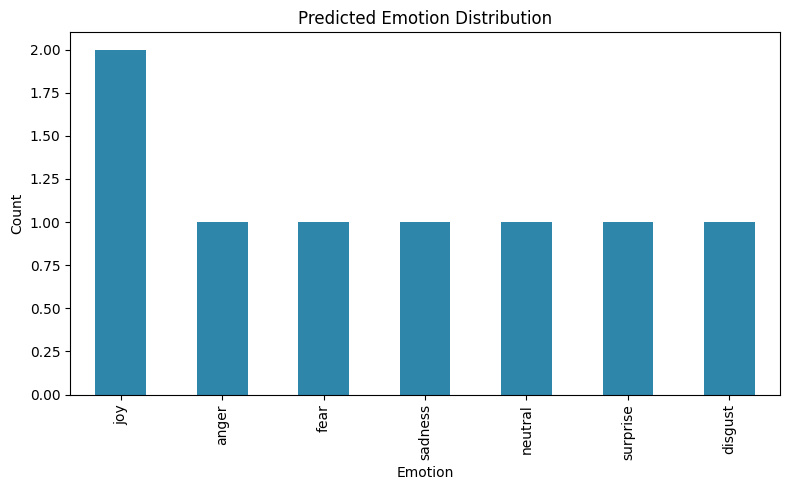

In [4]:
plt.figure(figsize=(8, 5))
eval_df["emotion"].value_counts().plot(kind="bar", color="#2E86AB")
plt.title("Predicted Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

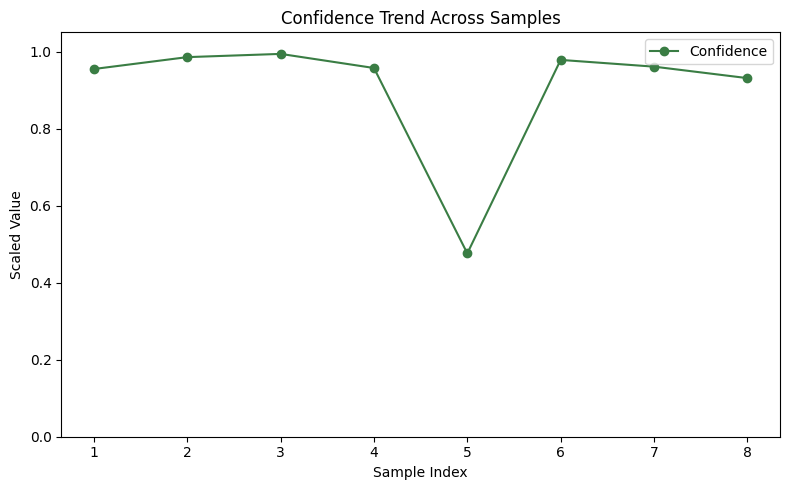

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(eval_df) + 1), eval_df["confidence"], marker="o", color="#3A7D44", label="Confidence")
plt.title("Confidence Trend Across Samples")
plt.xlabel("Sample Index")
plt.ylabel("Scaled Value")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

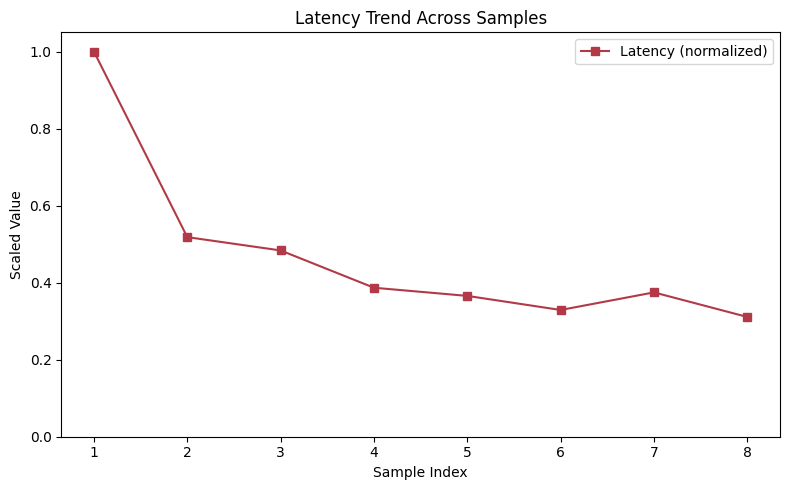

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(eval_df) + 1), eval_df["latency_ms"] / max(eval_df["latency_ms"].max(), 1), marker="s", color="#B23A48", label="Latency (normalized)")
plt.title("Latency Trend Across Samples")
plt.xlabel("Sample Index")
plt.ylabel("Scaled Value")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

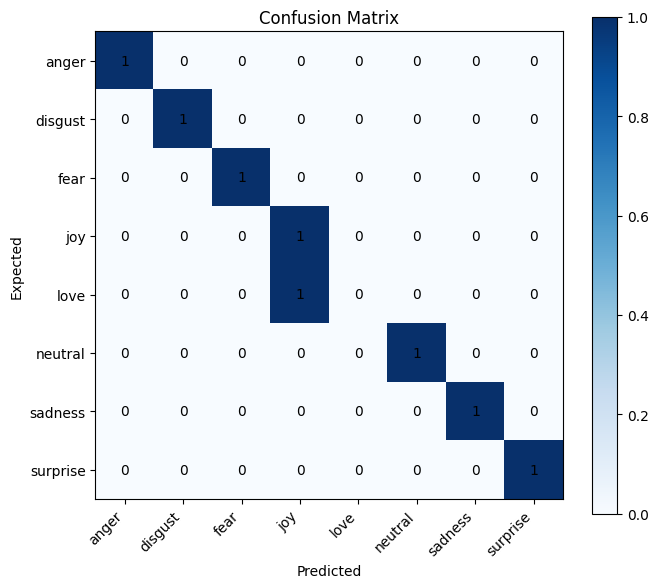

In [7]:
labels = sorted(set(eval_df["expected"]) | set(eval_df["emotion"]))
cm = pd.crosstab(eval_df["expected"], eval_df["emotion"], dropna=False)
cm = cm.reindex(index=labels, columns=labels, fill_value=0)

plt.figure(figsize=(7, 6))
plt.imshow(cm.values, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Expected")
plt.xticks(np.arange(len(labels)), labels, rotation=45, ha="right")
plt.yticks(np.arange(len(labels)), labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, int(cm.values[i, j]), ha="center", va="center", color="black")

plt.colorbar()
plt.tight_layout()
plt.show()

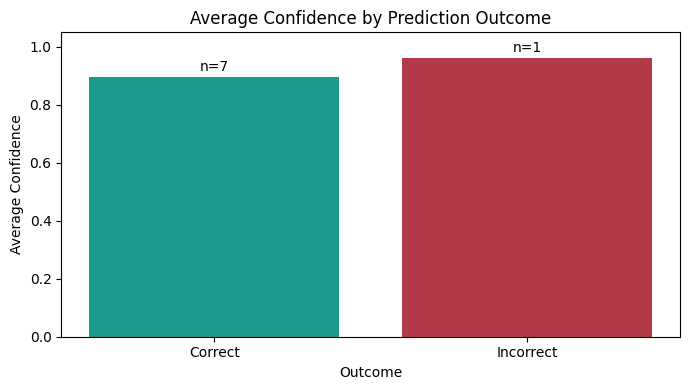

In [8]:
confidence_by_outcome = eval_df.groupby("correct")["confidence"].mean().reindex([1, 0], fill_value=0)
count_by_outcome = eval_df.groupby("correct").size().reindex([1, 0], fill_value=0)

labels = ["Correct", "Incorrect"]
values = [confidence_by_outcome.loc[1], confidence_by_outcome.loc[0]]
counts = [count_by_outcome.loc[1], count_by_outcome.loc[0]]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, values, color=["#1B998B", "#B23A48"])
plt.title("Average Confidence by Prediction Outcome")
plt.xlabel("Outcome")
plt.ylabel("Average Confidence")
plt.ylim(0, 1.05)

for bar, n in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"n={int(n)}", ha="center")

plt.tight_layout()
plt.show()

In [10]:
print("Final Evaluation Metrics")
print("-" * 30)
print(f"Accuracy: {eval_df['correct'].mean():.2%}")
print(f"Avg confidence: {eval_df['confidence'].mean():.2%}")
print(f"Avg latency: {eval_df['latency_ms'].mean():.2f} ms")

Final Evaluation Metrics
------------------------------
Accuracy: 87.50%
Avg confidence: 90.48%
Avg latency: 36.85 ms
